In [ ]:
from ephys_behavior import correlation_results_summary_combined

# 1) Let the function discover every correlations CSV automatically
summary = correlation_results_summary_combined(
    save_result=True,                       # write to disk
    save_name='sig_dir_all_sessions'    # custom file name
)

In [2]:
from ephys_behavior import correlation_results_summary_combined

# 1) Let the function discover every correlations CSV automatically
summary = correlation_results_summary_combined(
    save_result=True,                       # write to disk
    save_name='sig_dir_all_sessions',    # custom file name
    search_folder="/root/capsule/scratch/correlation_results2",
    save_folder="/root/capsule/scratch/correlation_results2"
)

Found 37 correlation result file(s)/folder(s):
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753125_2024-10-14_15-37-15_sorted_2024-11-09_20-07-38.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753125_2024-10-15_16-16-22_sorted_2024-11-09_19-57-50.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753126_2024-10-10_17-51-24_sorted_2025-02-21_13-56-40.zarr
  • /root/capsule/scratch/correlation_results2/correlations_multi-ecephys_753126_2024-10-11_13-14-24_sorted_2024-11-09_19-18-21.zarr
  • /root/capsule/scra

In [3]:
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/scratch/correlation_results/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)



print("Rows:", len(ds))
display(ds.head())             # in a notebook


Rows: 69951


,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval,ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef,...,simple_LR-g9-s1-d0-f_stat,simple_LR-g9-s1-d0-hqic,simple_LR-g9-s1-d0-llf,simple_LR-g9-s1-d0-rsq,simple_LR-g9-s1-d0-rsq_adj,simple_LR-g9-s1-d0-sigma2,source_file,time_window,unit_index,z_score
index,,,,,,,,,,,,,,,,,,,,,
0,0.152402,0.120495,1.556492,0.089148,0.368827,0.899832,-0.020901,0.833563,-0.210290,0.123322,...,2.768431,NaN,-779.059920,0.007695,0.004915,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,9,False
1,0.167072,0.079958,1.756028,-0.192590,0.042605,-2.034970,0.118241,0.214108,1.244609,0.123618,...,0.000597,NaN,-681.181162,0.000002,-0.002799,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,9,False
2,0.032352,0.800006,0.253533,-0.185525,0.147099,-1.453067,0.192337,0.132300,1.508614,-0.048639,...,5.735645,NaN,-644.272340,0.015812,0.013055,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2_-1_0,9,False
3,0.083825,0.427871,0.793764,-0.033850,0.748948,-0.320279,0.006011,0.954721,0.056821,0.079978,...,1.378883,NaN,-770.762613,0.003848,0.001057,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,14,False
4,0.110529,0.181864,1.337697,-0.210355,0.010194,-2.583169,0.095946,0.242588,1.170519,0.210518,...,0.391524,NaN,-681.769576,0.001096,-0.001703,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,14,False


In [ ]:
import importlib
import ephys_behavior_visualization
importlib.reload(ephys_behavior_visualization)

In [2]:
# Combined runner for polar / diagonal plots across models and regions
# All comments are in English.

from itertools import product
from typing import Dict, List, Iterable, Tuple, Any, Optional, Union

from ephys_behavior_visualization import (
    plot_angle_fraction_polar,
    plot_diagonal_significance,
)

RegionSpec = Union[str, Iterable[str]]

def _ensure_list(x) -> List:
    if x is None:
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]

def _normalize_region_specs(regions: Iterable[RegionSpec]) -> List[Tuple[RegionSpec, str]]:
    """
    Convert user-provided region specs (strings or iterables of strings) into a list of
    (region_arg, label) pairs.

    - For a single string r: region_arg=r, label=r or 'ALL' if r==''.
    - For an iterable of strings G: region_arg=list(G), label='MD+RE' (joined with '+').
      If the downstream function does not accept lists, we'll fallback to a regex OR string 'MD|RE'.
    """
    out: List[Tuple[RegionSpec, str]] = []
    for spec in _ensure_list(regions):
        if isinstance(spec, str):
            label = spec if spec != "" else "ALL"
            out.append((spec, label))
        elif isinstance(spec, (list, tuple, set)):
            group = [str(s) for s in spec]
            label = "+".join(group) if group else "EMPTY_GROUP"
            out.append((group, label))
        else:
            raise TypeError(f"Unsupported region spec type: {type(spec)}. "
                            f"Use a string or an iterable of strings.")
    return out

def get_model_config() -> Dict[str, Dict[str, str]]:
    """
    Returns a dict mapping model keys to the columns used for x/y and p-values.
    Keys are chosen to be explicit about the comparison.
    """
    return {

        # Q-learning: Reward vs SumQ (g1)
        "qlearn_reward_vs_sumQ_g1": {
            "col_x": "simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-coef",
            "col_y": "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef",
            "col_pval_x": "simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-pval",
            "col_pval_y": "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval",
        },
        # Q-learning: Reward vs ChosenQ (g0)
        "qlearn_reward_vs_chosenQ_g0": {
            "col_x": "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-coef",
            "col_y": "simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-coef",
            "col_pval_x": "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-pval",
            "col_pval_y": "simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-pval",
        },
        # Threshold model: Reward vs Value (g2)
        "threshold_reward_vs_value_g2": {
            "col_x": "simple_LR-ForagingCompareThreshold-reward-g2-s0-d0-coef",
            "col_y": "simple_LR-ForagingCompareThreshold-value-1-g2-s0-d0-coef",
            "col_pval_x": "simple_LR-ForagingCompareThreshold-reward-g2-s0-d0-pval",
            "col_pval_y": "simple_LR-ForagingCompareThreshold-value-1-g2-s0-d0-pval",
        },
    }

def run_model_plot(
    *,
    ds,
    plot_methods: Iterable[str] = ("polar", "diag"),
    models: Iterable[str] = ("qlearn_reward_vs_sumQ_g1", "qlearn_reward_vs_chosenQ_g0", "threshold_reward_vs_value_g2"),
    regions: Iterable[RegionSpec] = ("",),  # string or list-of-strings; "" means all regions
    time_window: str = "0.3_2",      # e.g. "0.3_2" or "0.3_2_-1_0" or "-1_0"
    include: str = "all",
    # Polar-specific options
    angle_bin_deg: int = 15,
    normalize: str = "selected",
    start_angle_deg: float = 0.0,
    show_reference_diagonals: bool = True,
    # Diagonal-specific options
    point_size: float = 1.0,
    fit_oval: bool = False,
) -> Dict[str, Dict[str, Dict[str, Tuple[Optional[Any], Optional[Any], Optional[Any]]]]]:
    """
    Runs selected plot(s) for each model x region(or region-group) combination.

    'regions' can be:
      - a single string (e.g., "SI")
      - a list of strings (e.g., ["MD", "RE"]) to form a group
      - a mix: ["SI", ["MD", "RE"], ""]  where "" means all regions

    Returns a nested dict:
      results[method][model_key][region_label] -> (fig, ax, tbl_or_None)
    """
    plot_methods = [m.lower() for m in _ensure_list(plot_methods)]
    models = _ensure_list(models)
    region_specs = _normalize_region_specs(regions)

    cfg = get_model_config()
    missing = [m for m in models if m not in cfg]
    if missing:
        raise ValueError(f"Unknown model key(s): {missing}. "
                         f"Available: {list(cfg.keys())}")

    results: Dict[str, Dict[str, Dict[str, Tuple[Optional[Any], Optional[Any], Optional[Any]]]]] = {}

    for method, model_key in product(plot_methods, models):
        if method not in results:
            results[method] = {}
        if model_key not in results[method]:
            results[method][model_key] = {}

        model_cols = cfg[model_key]

        for region_arg, region_label in region_specs:
            # Prefer passing list directly. If that raises a TypeError, fallback to regex OR.
            filter_region = region_arg
            if isinstance(region_arg, (list, tuple, set)):
                try:
                    # Try list directly first.
                    _ = region_arg  # no-op; clarity
                except Exception:
                    # Not really needed, but placeholder if you want a validation step.
                    pass

            if method == "polar":
                try:
                    fig, ax, tbl = plot_angle_fraction_polar(
                        ds=ds,
                        filter_region=filter_region,
                        time_window=time_window,
                        col_x=model_cols["col_x"],
                        col_y=model_cols["col_y"],
                        col_pval_x=model_cols["col_pval_x"],
                        col_pval_y=model_cols["col_pval_y"],
                        include=include,
                        angle_bin_deg=angle_bin_deg,
                        normalize=normalize,
                        start_angle_deg=start_angle_deg,
                        show_reference_diagonals=show_reference_diagonals,
                    )
                except TypeError:
                    # Fallback: convert list group to regex OR string
                    if isinstance(region_arg, (list, tuple, set)):
                        regex_or = "|".join(region_arg)
                        fig, ax, tbl = plot_angle_fraction_polar(
                            ds=ds,
                            filter_region=regex_or,
                            time_window=time_window,
                            col_x=model_cols["col_x"],
                            col_y=model_cols["col_y"],
                            col_pval_x=model_cols["col_pval_x"],
                            col_pval_y=model_cols["col_pval_y"],
                            include=include,
                            angle_bin_deg=angle_bin_deg,
                            normalize=normalize,
                            start_angle_deg=start_angle_deg,
                            show_reference_diagonals=show_reference_diagonals,
                        )
                    else:
                        raise
                results[method][model_key][region_label] = (fig, ax, tbl)

            elif method in ("diag", "diagonal", "diagonal_significance"):
                try:
                    out = plot_diagonal_significance(
                        ds=ds,
                        filter_region=filter_region,
                        time_window=time_window,
                        col_x=model_cols["col_x"],
                        col_y=model_cols["col_y"],
                        col_pval_x=model_cols["col_pval_x"],
                        col_pval_y=model_cols["col_pval_y"],
                        point_size=point_size,
                        fit_oval=fit_oval,
                    )
                except TypeError:
                    if isinstance(region_arg, (list, tuple, set)):
                        regex_or = "|".join(region_arg)
                        out = plot_diagonal_significance(
                            ds=ds,
                            filter_region=regex_or,
                            time_window=time_window,
                            col_x=model_cols["col_x"],
                            col_y=model_cols["col_y"],
                            col_pval_x=model_cols["col_pval_x"],
                            col_pval_y=model_cols["col_pval_y"],
                            point_size=point_size,
                            fit_oval=fit_oval,
                        )
                    else:
                        raise

                if isinstance(out, tuple) and len(out) >= 2:
                    fig, ax = out[:2]
                else:
                    fig = ax = None
                results[method][model_key][region_label] = (fig, ax, None)

            else:
                raise ValueError(f"Unknown plot method: {method}")

    return results

# -------------------------
# EXAMPLES
# -------------------------

# 1) Single regions + a grouped region + ALL:
# results = run_model_plot(
#     ds=ds,
#     plot_methods=["polar", "diag"],
#     models=["qlearn_reward_vs_sumQ_g1", "qlearn_reward_vs_chosenQ_g0", "threshold_reward_vs_value_g2"],
#     regions=["SI", ["MD", "RE"], ""],   # list of lists supported
#     time_window="0.3_2",
# )

# 2) Only grouped regions, diagonal only:
# results = run_model_plot(
#     ds=ds,
#     plot_methods="diag",
#     models="qlearn_reward_vs_chosenQ_g0",
#     regions=[["MD", "RE"], ["SI", "ACA"]],
#     time_window="0.3_2_-1_0",
# )


In [ ]:
 results = run_model_plot(
     ds=ds,
     plot_methods=["polar", "diag"],
     models=["qlearn_reward_vs_chosenQ_g0"],
     regions=[["MD"],[ "PL5","PL6a","ILA5","ILA6a"],["SI","MA"] ],
     time_window="0.3_2_-1_0",  # or "0.3_2_-1_0" or "-1_0"
     include="all",
     angle_bin_deg=15,
     normalize="selected",
     start_angle_deg=0,
     show_reference_diagonals=True,
     point_size=1,
     fit_oval=False,
 )

In [ ]:
 results = run_model_plot(
     ds=ds,
     plot_methods=["polar", "diag"],
     models=["qlearn_reward_vs_sumQ_g1"],
     regions=[["MD"],[ "PL5","PL6a","ILA5","ILA6a"],["SI","MA"] ],
     time_window="0.3_2",  # or "0.3_2_-1_0" or "-1_0"
     include="all",
     angle_bin_deg=15,
     normalize="selected",
     start_angle_deg=0,
     show_reference_diagonals=True,
     point_size=1,
     fit_oval=False,
 )

In [ ]:
import importlib
import ephys_behavior_visualization
importlib.reload(ephys_behavior_visualization)

from ephys_behavior_visualization import plot_stat_3d_by_ccf

fig, ax, table = plot_stat_3d_by_ccf(
    ds,
    column="simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-tval",
    filter_region=["MD", "SI","MA","PL5","PL6a","ILA5","ILA6a","MOs2/3","MOs5","MOs6a"],           # or ["MD","PL"] or "!MD" or ""
    time_window="0.3_2",
    symmetric_color=True,
)



In [ ]:
"simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-tval"
"simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-tval"

"simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-tval"

            "col_x": "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-coef",
            "col_y": "simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-coef",

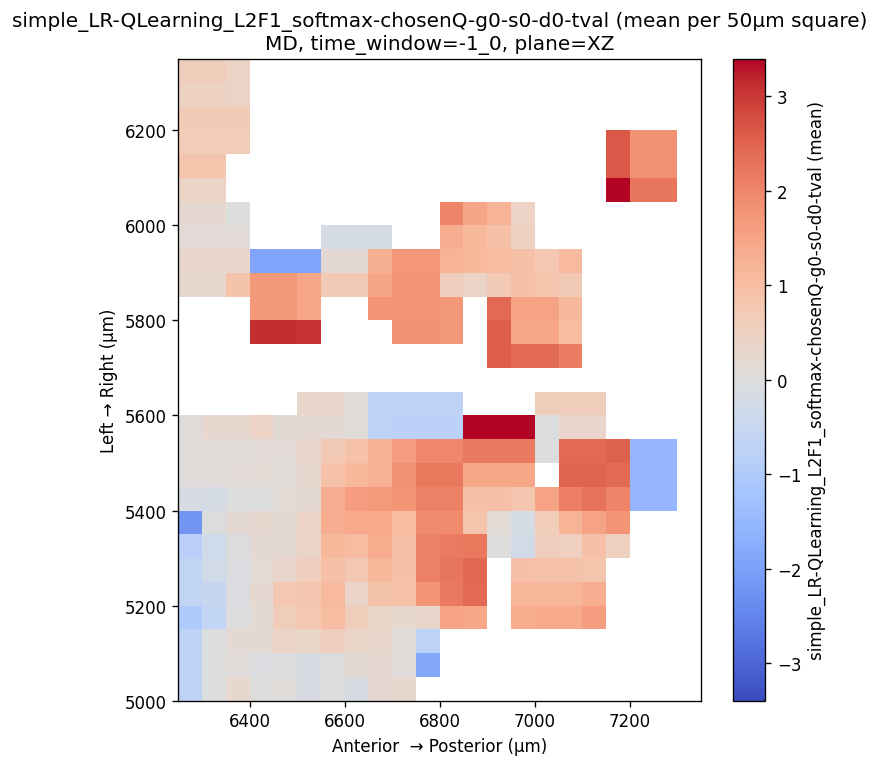

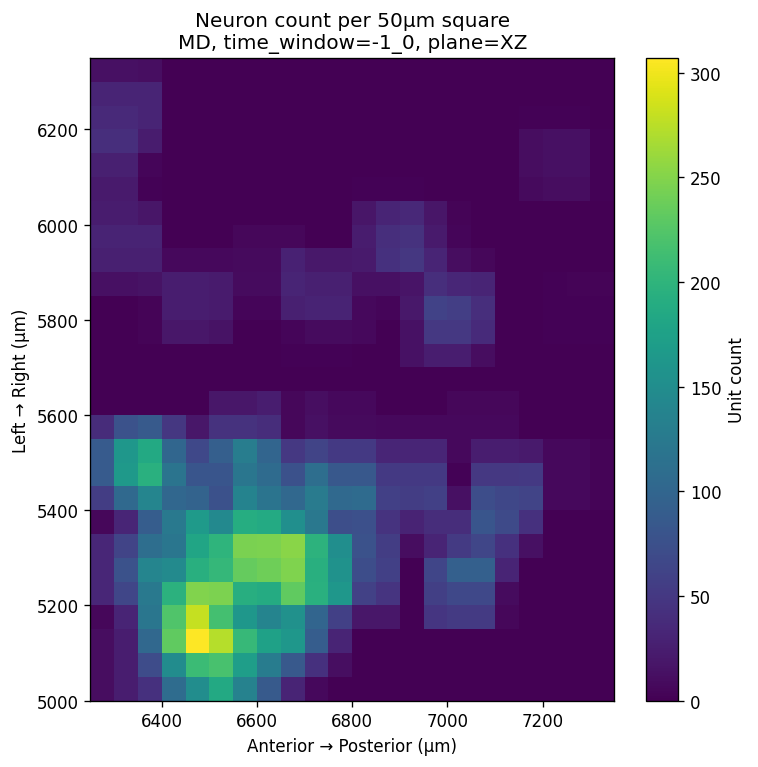

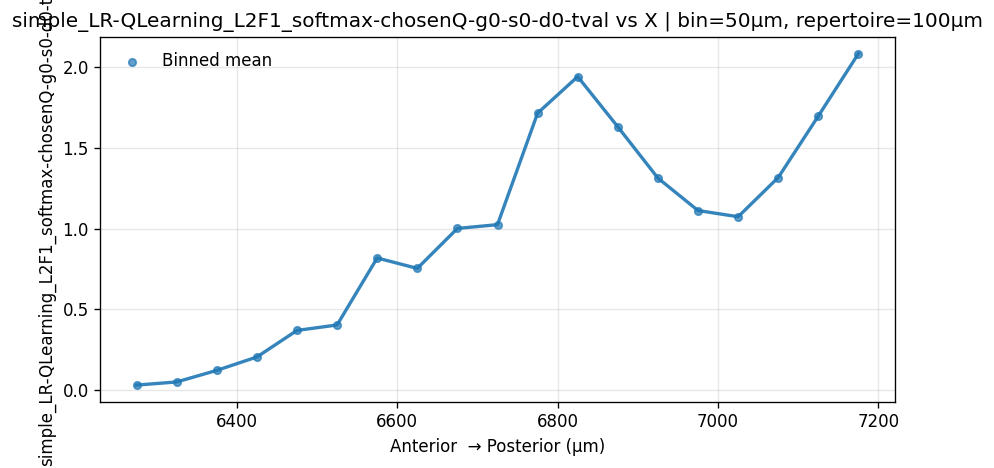

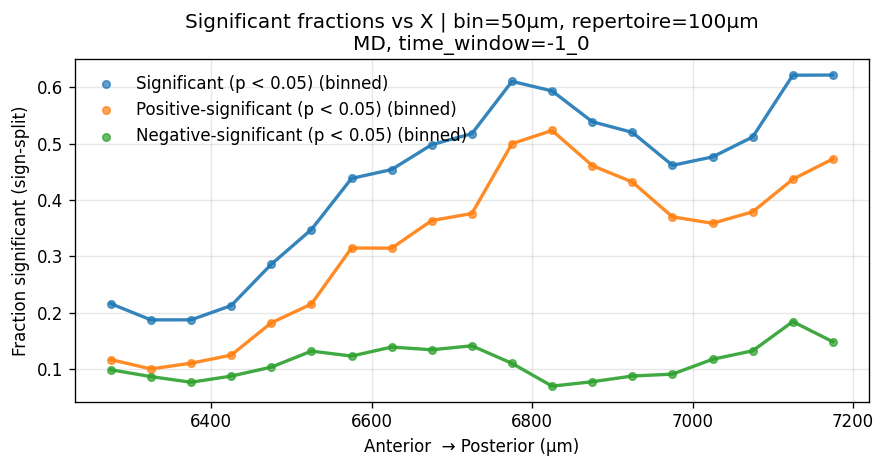

(<Figure size 900x480 with 1 Axes>,
 <Axes: title={'center': 'Significant fractions vs X | bin=50µm, repertoire=100µm\nMD, time_window=-1_0'}, xlabel='Anterior  → Posterior (µm)', ylabel='Fraction significant (sign-split)'>,
     bin_center_um  count  n_sig_both  n_sig_pos  n_sig_neg  fraction_both  \
 0          6275.0  222.0        48.0       26.0       22.0       0.216216   
 1          6325.0  368.0        69.0       37.0       32.0       0.187500   
 2          6375.0  533.0       100.0       59.0       41.0       0.187617   
 3          6425.0  592.0       126.0       74.0       52.0       0.212838   
 4          6475.0  713.0       204.0      130.0       74.0       0.286115   
 5          6525.0  719.0       250.0      155.0       95.0       0.347705   
 6          6575.0  689.0       302.0      217.0       85.0       0.438316   
 7          6625.0  610.0       277.0      192.0       85.0       0.454098   
 8          6675.0  550.0       274.0      200.0       74.0       0.49818

In [13]:
import importlib
import ephys_behavior_visualization
importlib.reload(ephys_behavior_visualization)

from ephys_behavior_visualization import plot_stat_2d_grid_by_ccf, plot_unit_count_2d_grid_by_ccf,plot_stat_profile_along_axis_by_ccf,plot_significant_fraction_along_axis_by_ccf


latent="simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-tval"
latent_p="simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-pval"

latent="simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-tval"
latent_p="simple_LR-QLearning_L2F1_softmax-chosenQ-g0-s0-d0-pval"


time_window="0.3_2"
time_window="-1_0"
region=["MD"]
bin_size_um=50
repertoire_um=100
# 200 µm grid but each neuron covers 400 µm neighborhood
plot_stat_2d_grid_by_ccf(
    ds,
    column=latent,
    filter_region=region,
    time_window=time_window,
    plane="xz",
    bin_size_um=bin_size_um,
    repertoire_um=repertoire_um,   # each neuron influences a 400×400 µm area
    min_points_per_square=5,
   # vmin=-10,
   # vmax=10
   # flip_axis="z",
   # flip_mid_um=5700,
   # flip_side="greater",
)

# Matching count heatmap
plot_unit_count_2d_grid_by_ccf(
    ds,
    filter_region=region,
    time_window=time_window,
    plane="xz",
    bin_size_um=bin_size_um,
    repertoire_um=repertoire_um,
   # flip_axis="z",
  #  flip_mid_um=5700,
  #  flip_side="greater",
    log_scale=False,
)


# Average t-value vs Right–Left (Z) with 200 µm bins, Gaussian smoothing σ=400 µm
plot_stat_profile_along_axis_by_ccf(
    ds,
    column=latent,
    filter_region=region,
    time_window=time_window,
    axis="x",
    bin_size_um=bin_size_um,
    repertoire_um=repertoire_um,       # each unit influences ±200 µm
    smooth="none",
    min_points_per_bin=30,
    smooth_um=50
)


plot_significant_fraction_along_axis_by_ccf(
    ds,
    column=latent_p,          # p-value column
    effect_column=latent,
    filter_region=region,
    time_window=time_window,
    axis="x",
    bin_size_um=bin_size_um,
    repertoire_um=repertoire_um,
    smooth="none",
    min_points_per_bin=30,
    alpha_level=0.05,          # OK here
    which="all3"
    
)

